# YUPA INSURANCE

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

from datetime import datetime

In [27]:
df = pd.read_csv('claims_yupa.csv')

#display first few rows of the dataframe
df.head()

,Claim ID,Hospital Name,Patient ID,Procedure,Claim Amount,Date,Status
0,C001,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-10,Settled
1,C002,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-12,Settled
2,C003,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-15,Settled
3,C004,Metro Hosp.,P124,Appendectomy,"80,000",2025-01-11,Settled
4,C005,CityCare Hosp.,P125,Cataract Surgery,"40,000",2025-01-13,Settled


In [28]:
print(df.shape)

df.head()

df.info()

df.describe(include='all')

(100, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Claim ID       100 non-null    object
 1   Hospital Name  100 non-null    object
 2   Patient ID     100 non-null    object
 3   Procedure      100 non-null    object
 4   Claim Amount   100 non-null    object
 5   Date           100 non-null    object
 6   Status         100 non-null    object
dtypes: object(7)
memory usage: 5.6+ KB


,Claim ID,Hospital Name,Patient ID,Procedure,Claim Amount,Date,Status
count,100,100,100,100,100,100,100
unique,100,3,93,7,7,98,1
top,C001,CityCare Hosp.,P123,Knee Surgery,"1,20,000",2025-01-20,Settled
freq,1,47,8,31,31,2,100


In [29]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.quarter

In [30]:
# ==========================
# BASIC DATASET STATISTICS
# ==========================

print("=" * 50)
print("        YUPA INSURANCE DATASET SUMMARY")
print("=" * 50)

# Number of Claims
num_claims = len(df)

# Number of Hospitals
num_hospitals = df["Hospital Name"].nunique()

# Number of Patients
num_patients = df["Patient ID"].nunique()

# Number of Procedures
num_procedures = df["Procedure"].nunique()

# Total Claim Amount
total_claim = df["Claim Amount"].sum()

# Average Claim Amount
# convert Claim Amount to numeric (remove commas) and recompute totals/average
df["Claim Amount"] = pd.to_numeric(df["Claim Amount"].astype(str).str.replace(",", "", regex=False), errors="coerce")
total_claim = df["Claim Amount"].sum()
avg_claim = df["Claim Amount"].mean()

# Median Claim Amount
median_claim = df["Claim Amount"].median()

# Minimum Claim Amount
min_claim = df["Claim Amount"].min()

# Maximum Claim Amount
max_claim = df["Claim Amount"].max()

# Print Results
print(f"Total Claims           : {num_claims}")
print(f"Unique Hospitals       : {num_hospitals}")
print(f"Unique Patients        : {num_patients}")
print(f"Unique Procedures      : {num_procedures}")
print("-" * 50)
print(f"Total Claim Amount     : ₹{total_claim:,.2f}")
print(f"Average Claim Amount   : ₹{avg_claim:,.2f}")
print(f"Median Claim Amount    : ₹{median_claim:,.2f}")
print(f"Minimum Claim Amount   : ₹{min_claim:,.2f}")
print(f"Maximum Claim Amount   : ₹{max_claim:,.2f}")
print("=" * 50)

        YUPA INSURANCE DATASET SUMMARY
Total Claims           : 100
Unique Hospitals       : 3
Unique Patients        : 93
Unique Procedures      : 7
--------------------------------------------------
Total Claim Amount     : ₹9,515,000.00
Average Claim Amount   : ₹95,150.00
Median Claim Amount    : ₹80,000.00
Minimum Claim Amount   : ₹35,000.00
Maximum Claim Amount   : ₹200,000.00


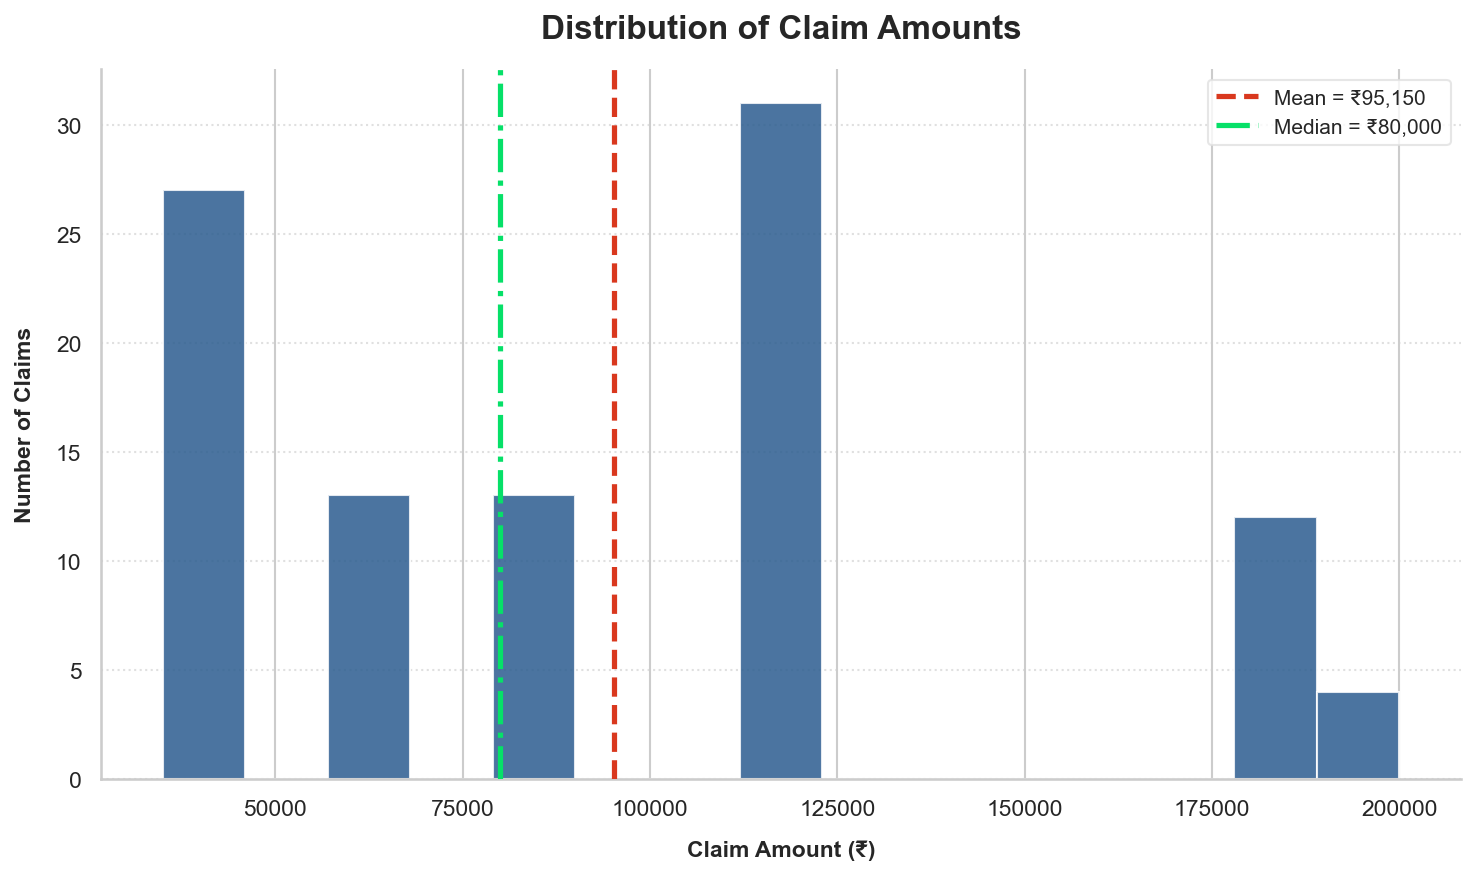

In [31]:
# Claim Amount Distribution with Mean & Median

mean_claim = (
    pd.to_numeric(
        df["Claim Amount"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )
    .mean()
)
median_claim = (
    pd.to_numeric(
        df["Claim Amount"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )
    .median()
)

plt.figure(figsize=(10, 6), dpi=150)

plt.hist(
    df["Claim Amount"],
    bins=15,
    edgecolor="white",
    color="#2b5c8f",
    alpha=0.85,
    zorder=2,
)

plt.axvline(
    mean_claim,
    color="#d9381e",
    linestyle="--",
    linewidth=2.5,
    label=f"Mean = ₹{mean_claim:,.0f}",
    zorder=3,
)

plt.axvline(
    median_claim,
    color="#06e068",
    linestyle="-.",
    linewidth=2.5,
    label=f"Median = ₹{median_claim:,.0f}",
    zorder=3,
)

plt.title(
    "Distribution of Claim Amounts", fontsize=16, fontweight="bold", pad=15
)
plt.xlabel("Claim Amount (₹)", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Number of Claims", fontsize=11, fontweight="bold", labelpad=10)

plt.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    fontsize=10,
)

plt.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc", zorder=1)

# Remove top and right border spines for a cleaner aesthetic
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

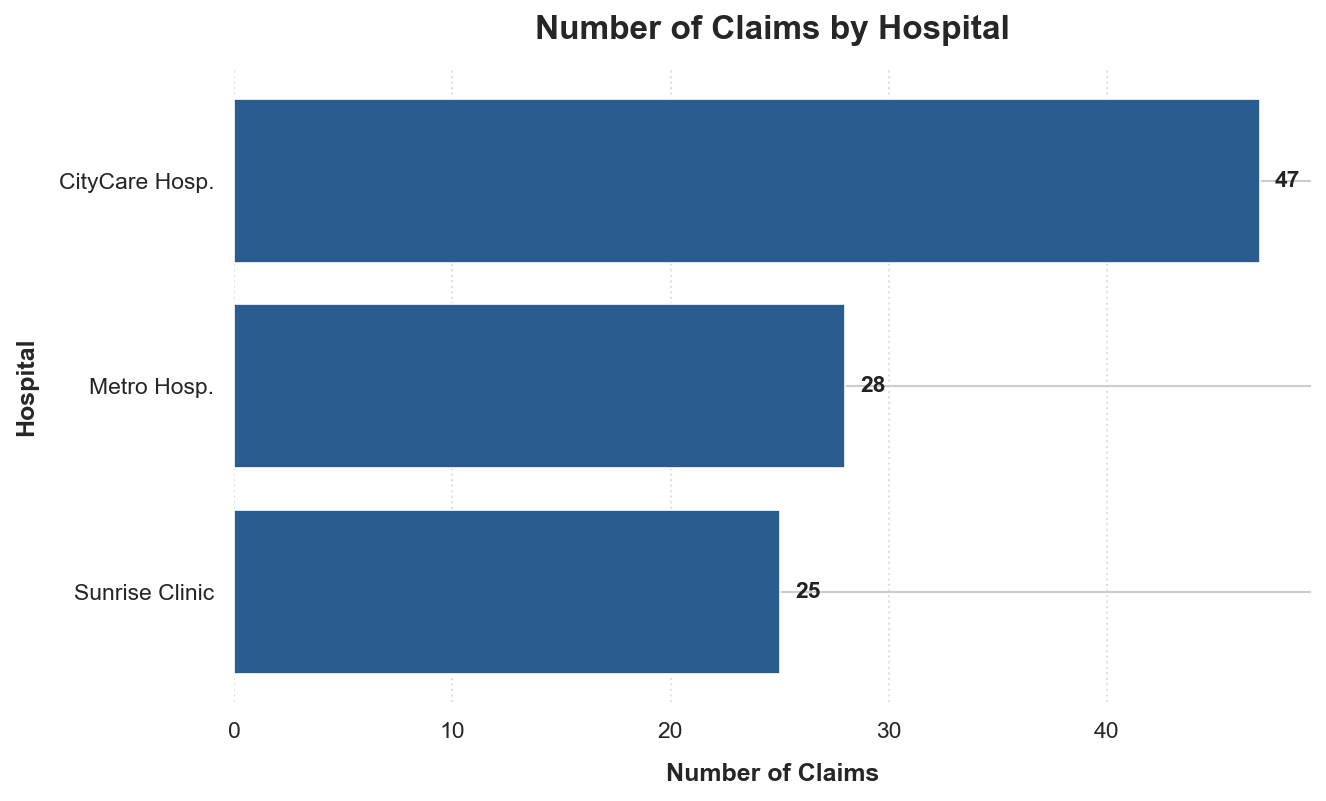

Claims by Hospital
-----------------------------------
Hospital Name
CityCare Hosp.    47
Metro Hosp.       28
Sunrise Clinic    25
Name: count, dtype: int64


In [32]:
# Number of Claims by Hospital

hospital_counts = df["Hospital Name"].value_counts()

plt.figure(figsize=(9, 5.5), dpi=150)

plt.barh(
    hospital_counts.index,
    hospital_counts.values,
    color="#2b5c8f",
    edgecolor="white",
    linewidth=0.8,
    zorder=2,
)

plt.title(
    "Number of Claims by Hospital", fontsize=16, fontweight="bold", pad=15
)
plt.xlabel("Number of Claims", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Hospital", fontsize=12, fontweight="bold", labelpad=10)

# Add value labels
for i, value in enumerate(hospital_counts.values):
    plt.text(
        value + (max(hospital_counts.values) * 0.015),
        i,
        str(value),
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#222222",
    )

plt.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc", zorder=1)

# Invert y-axis so top hospital appears at the top
plt.gca().invert_yaxis()

# Remove border spines for a cleaner aesthetic
ax = plt.gca()
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print("Claims by Hospital")
print("-" * 35)

hospital_counts = df["Hospital Name"].value_counts()

print(hospital_counts)

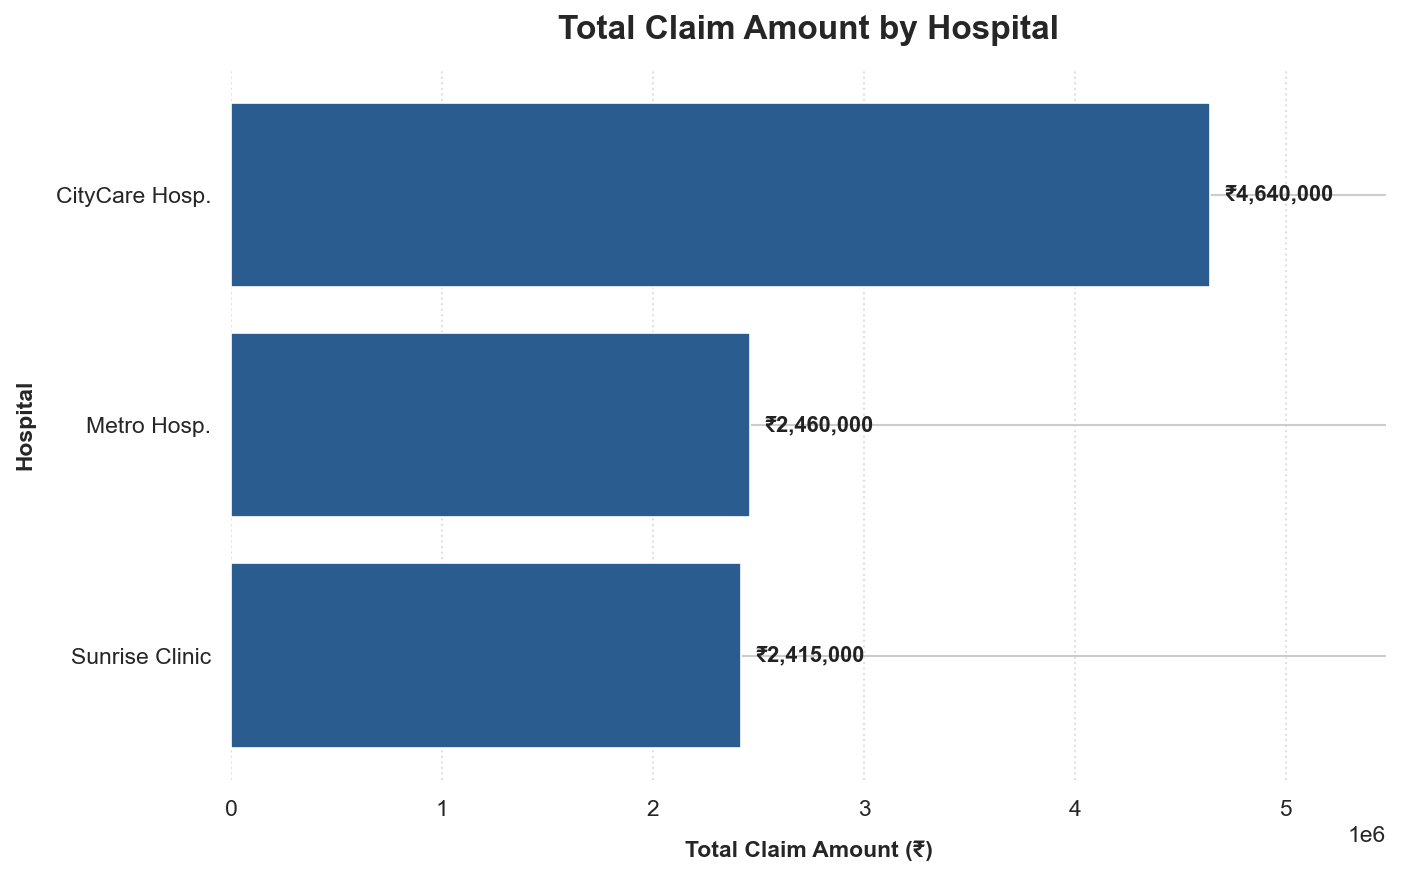

In [33]:
# Total Claim Amount by Hospital

# Group data by hospital and calculate total claim amount
hospital_claims = (
    df.groupby("Hospital Name")["Claim Amount"]
    .sum()
    .sort_values(ascending=True)
)

# Create figure
plt.figure(figsize=(9.5, 6), dpi=150)

# Horizontal bar chart
bars = plt.barh(
    hospital_claims.index,
    hospital_claims.values,
    color="#2b5c8f",
    edgecolor="white",
    linewidth=0.8,
    zorder=2,
)

# Dynamic padding calculation based on maximum value
max_val = hospital_claims.max() if not hospital_claims.empty else 1
offset = max_val * 0.015

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color="#222222",
    )

# Labels and title
plt.title(
    "Total Claim Amount by Hospital", fontsize=16, fontweight="bold", pad=15
)
plt.xlabel(
    "Total Claim Amount (₹)", fontsize=11, fontweight="bold", labelpad=10
)
plt.ylabel("Hospital", fontsize=11, fontweight="bold", labelpad=10)

plt.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc", zorder=1)

# Set x-limit to give room for data labels
plt.xlim(0, max_val * 1.18)

# Remove border spines for a cleaner aesthetic
ax = plt.gca()
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

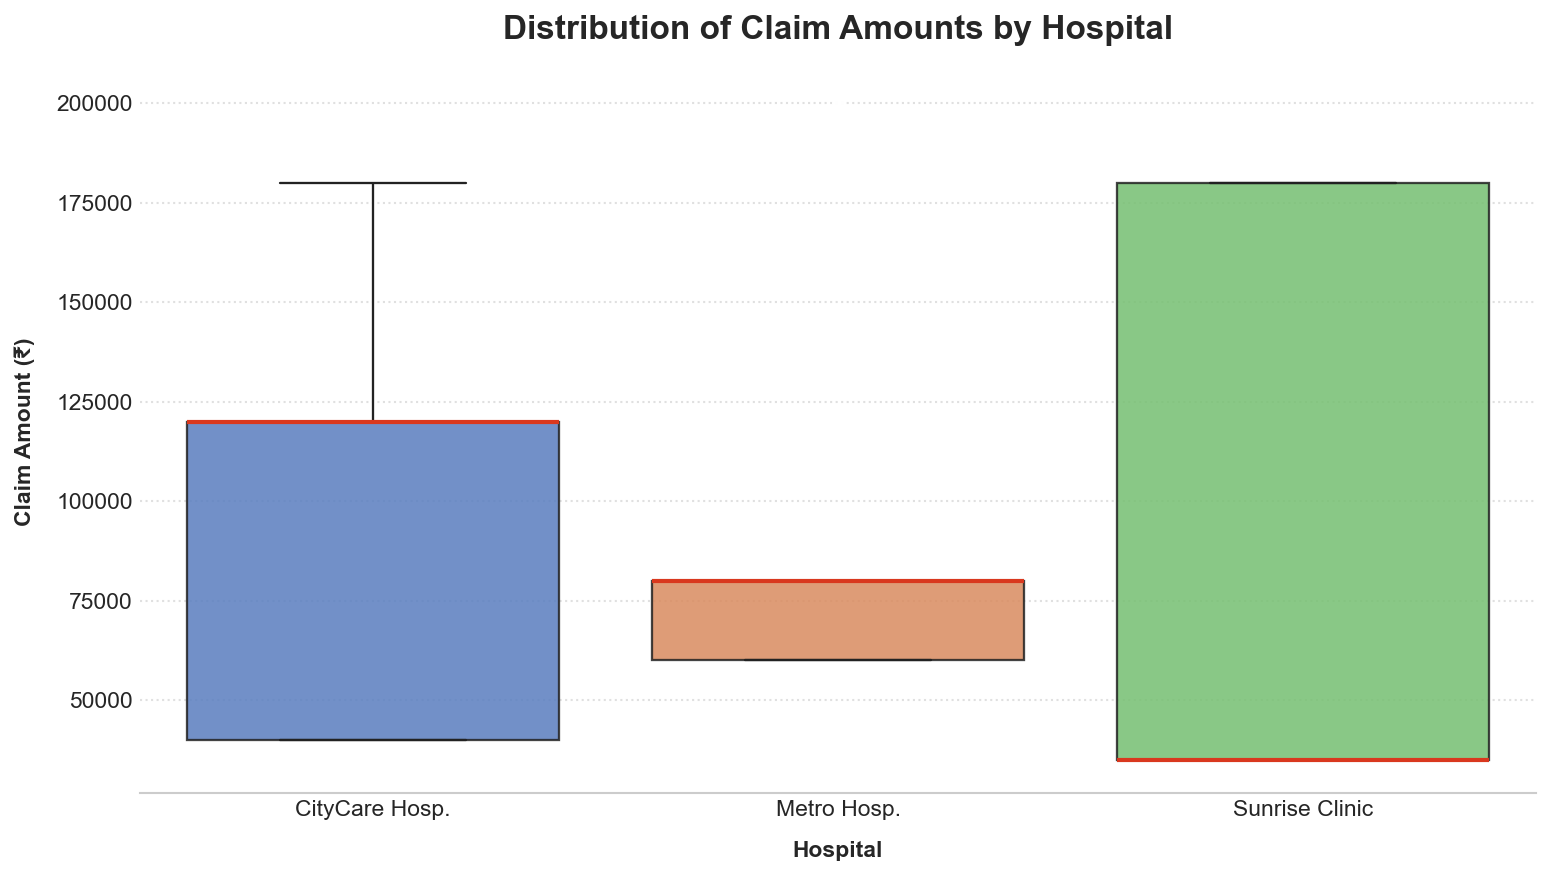

In [34]:


# Clean theme setup
plt.style.use("seaborn-v0_8-whitegrid")

# Claim Amount Distribution by Hospital
plt.figure(figsize=(10.5, 6), dpi=150)

ax = sns.boxplot(
    data=df,
    x="Hospital Name",
    y="Claim Amount",
    hue="Hospital Name",
    legend=False,
    palette="muted",
    flierprops=dict(
        marker="o",
        markerfacecolor="#ffffff",  # Neutral grey dot instead of bright red
        markeredgecolor="none",
        markersize=6,
        alpha=0.7,
    ),
    boxprops=dict(alpha=0.85, edgecolor="#222222", linewidth=1.1),
    whiskerprops=dict(color="#222222", linewidth=1.1),
    capprops=dict(color="#222222", linewidth=1.1),
    medianprops=dict(color="#d9381e", linewidth=2.0),
)

plt.title(
    "Distribution of Claim Amounts by Hospital",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Hospital", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Claim Amount (₹)", fontsize=11, fontweight="bold", labelpad=10)
# Format Y-axis ticks with comma formatting (e.g., ₹50,000)

plt.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc")

# Remove top, right, and left border spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

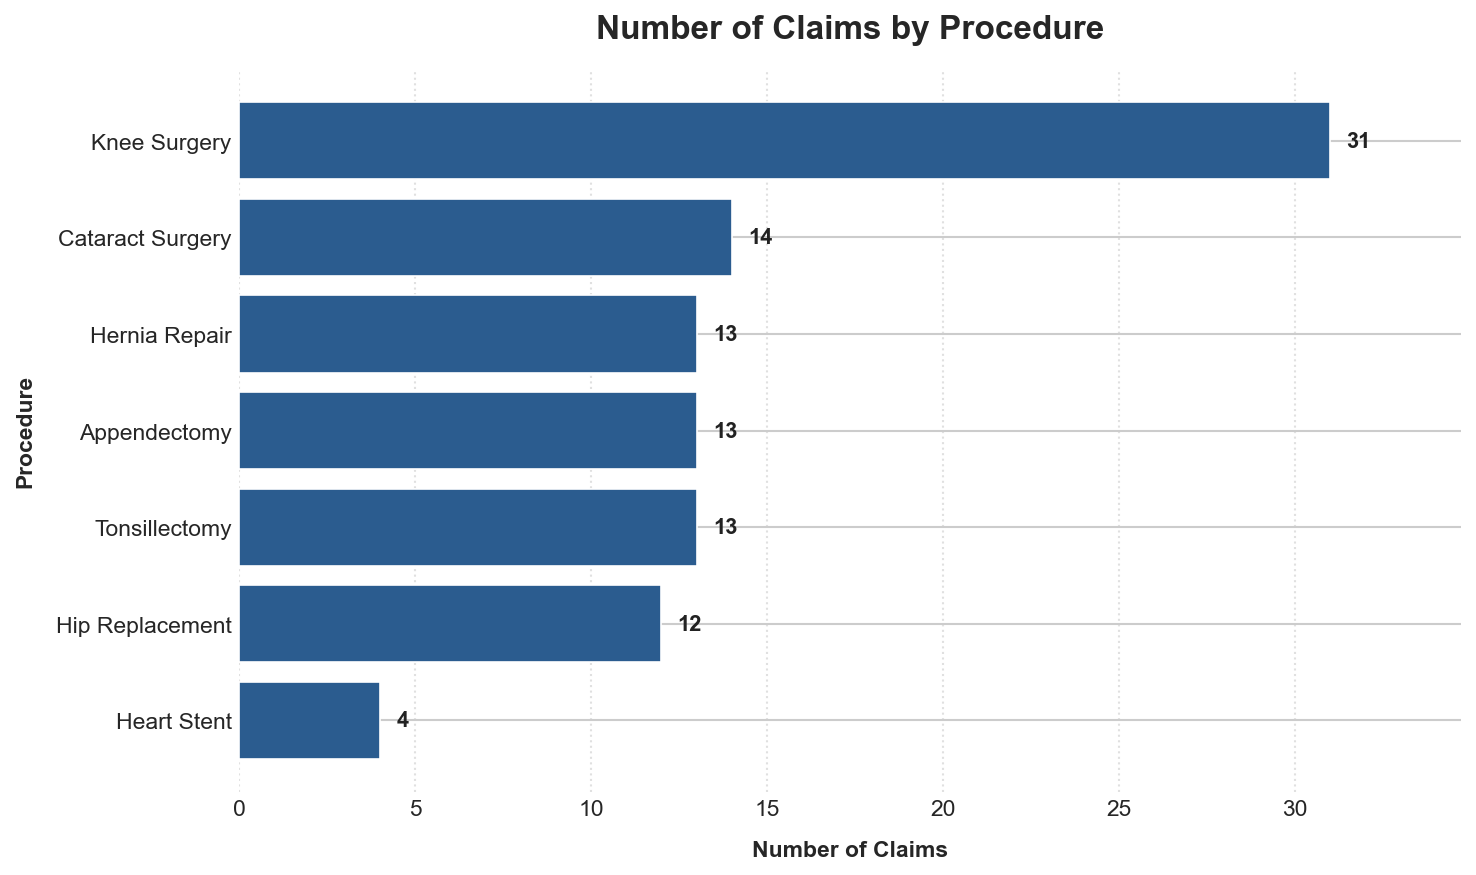

In [35]:
# Procedure Frequency

# Count each procedure
procedure_counts = (
    df["Procedure"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6), dpi=150)

bars = plt.barh(
    procedure_counts.index,
    procedure_counts.values,
    color="#2b5c8f",
    edgecolor="white",
    linewidth=0.8,
    zorder=2,
)

# Dynamic padding offset based on max frequency value
max_val = procedure_counts.max() if not procedure_counts.empty else 1
offset = max_val * 0.015

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color="#222222",
    )

plt.title(
    "Number of Claims by Procedure", fontsize=16, fontweight="bold", pad=15
)
plt.xlabel("Number of Claims", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Procedure", fontsize=11, fontweight="bold", labelpad=10)

plt.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc", zorder=1)

# Extend x-axis slightly so value labels don't get clipped
plt.xlim(0, max_val * 1.12)

# Remove border spines for a modern, borderless aesthetic
ax = plt.gca()
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

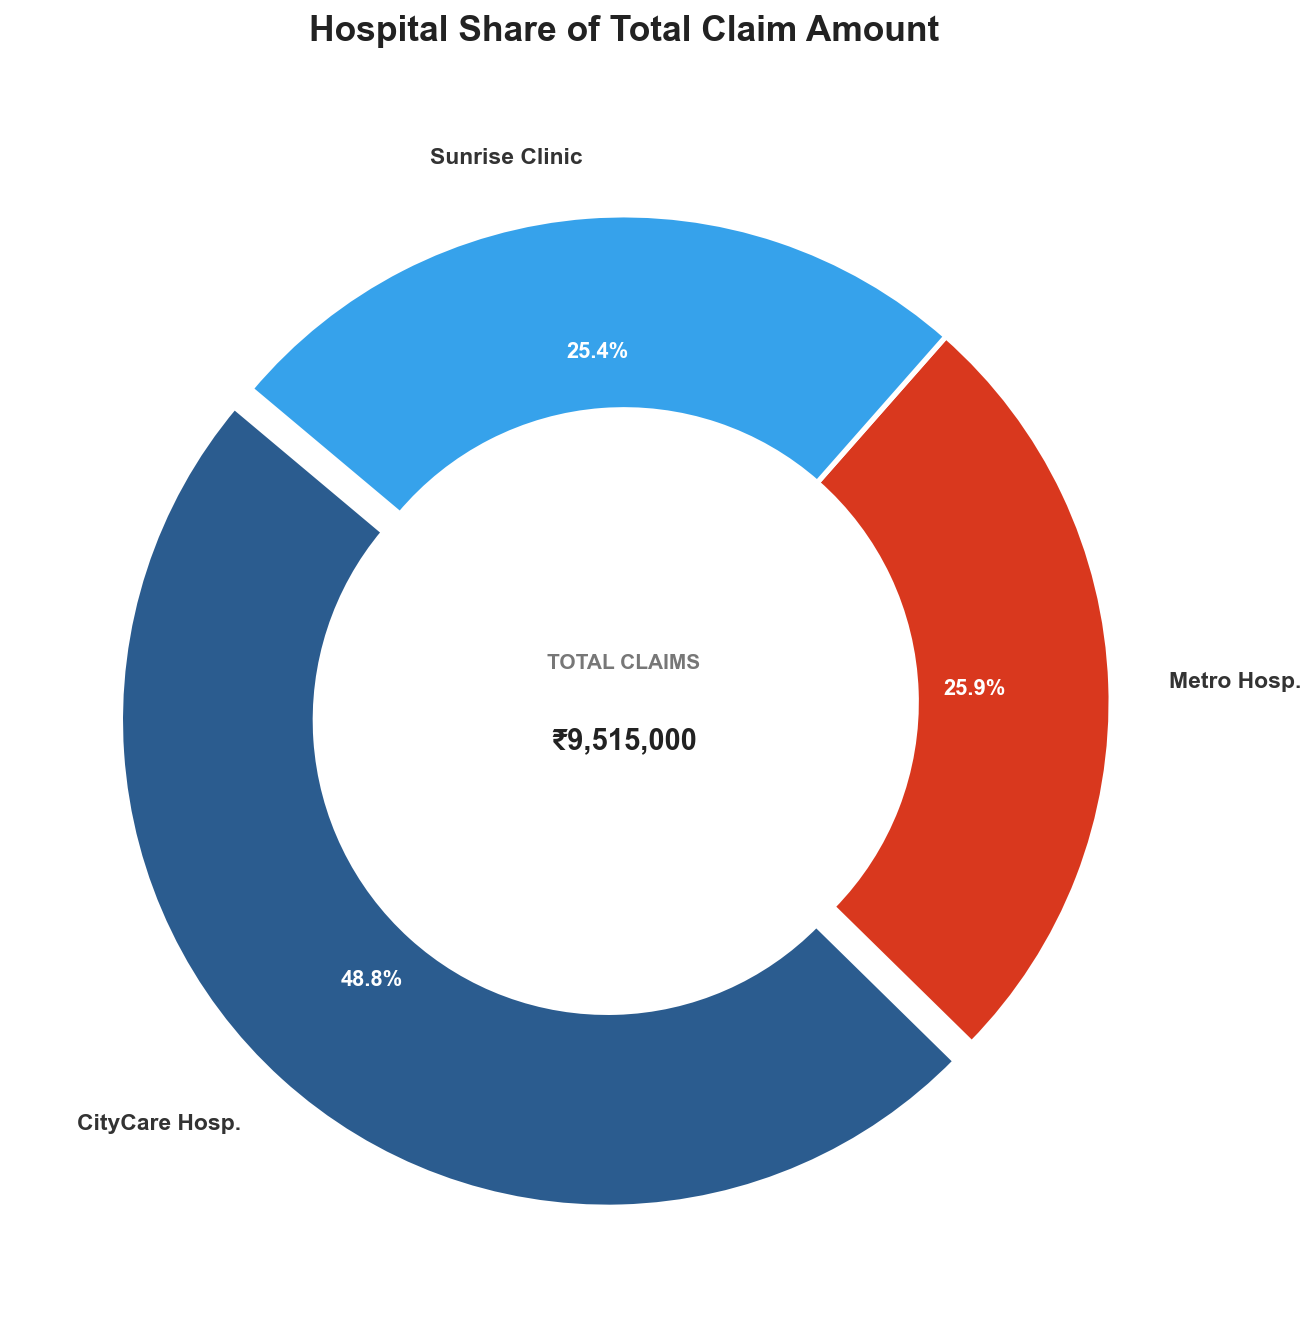

In [36]:
# Total claim amount by hospital

hospital_claims = (
    df.groupby("Hospital Name")["Claim Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Total overall claim amount for the center text label
total_claim_val = hospital_claims.sum()

# Professional Palette
colors = ["#2b5c8f", "#d9381e", "#36a2eb", "#ffcd56", "#4bc0c0", "#9966ff"]

plt.figure(figsize=(9, 9), dpi=150)

wedges, texts, autotexts = plt.pie(
    hospital_claims,
    labels=hospital_claims.index,
    startangle=140,
    explode=[0.05] + [0] * (len(hospital_claims) - 1),  # Pop out top slice
    autopct="%1.1f%%",
    pctdistance=0.72,  # Percentages inside
    labeldistance=1.12,  # Labels outside
    colors=colors[: len(hospital_claims)],
    wedgeprops=dict(
        width=0.40, edgecolor="white", linewidth=2.5, antialiased=True
    ),
)

# Beautify slice labels
plt.setp(texts, fontsize=11, fontweight="bold", color="#333333")

# Beautify percentages
plt.setp(autotexts, fontsize=10.5, fontweight="bold", color="white")

# Add Center Metric Callout (Total Amount) inside the donut hole
plt.gca().text(
    0,
    0.08,
    "TOTAL CLAIMS",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color="#777777",
)

plt.gca().text(
    0,
    -0.08,
    f"₹{total_claim_val:,.0f}",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="#222222",
)

plt.title(
    "Hospital Share of Total Claim Amount",
    fontsize=17,
    fontweight="bold",
    pad=25,
    color="#222222",
)

plt.tight_layout()
plt.show()

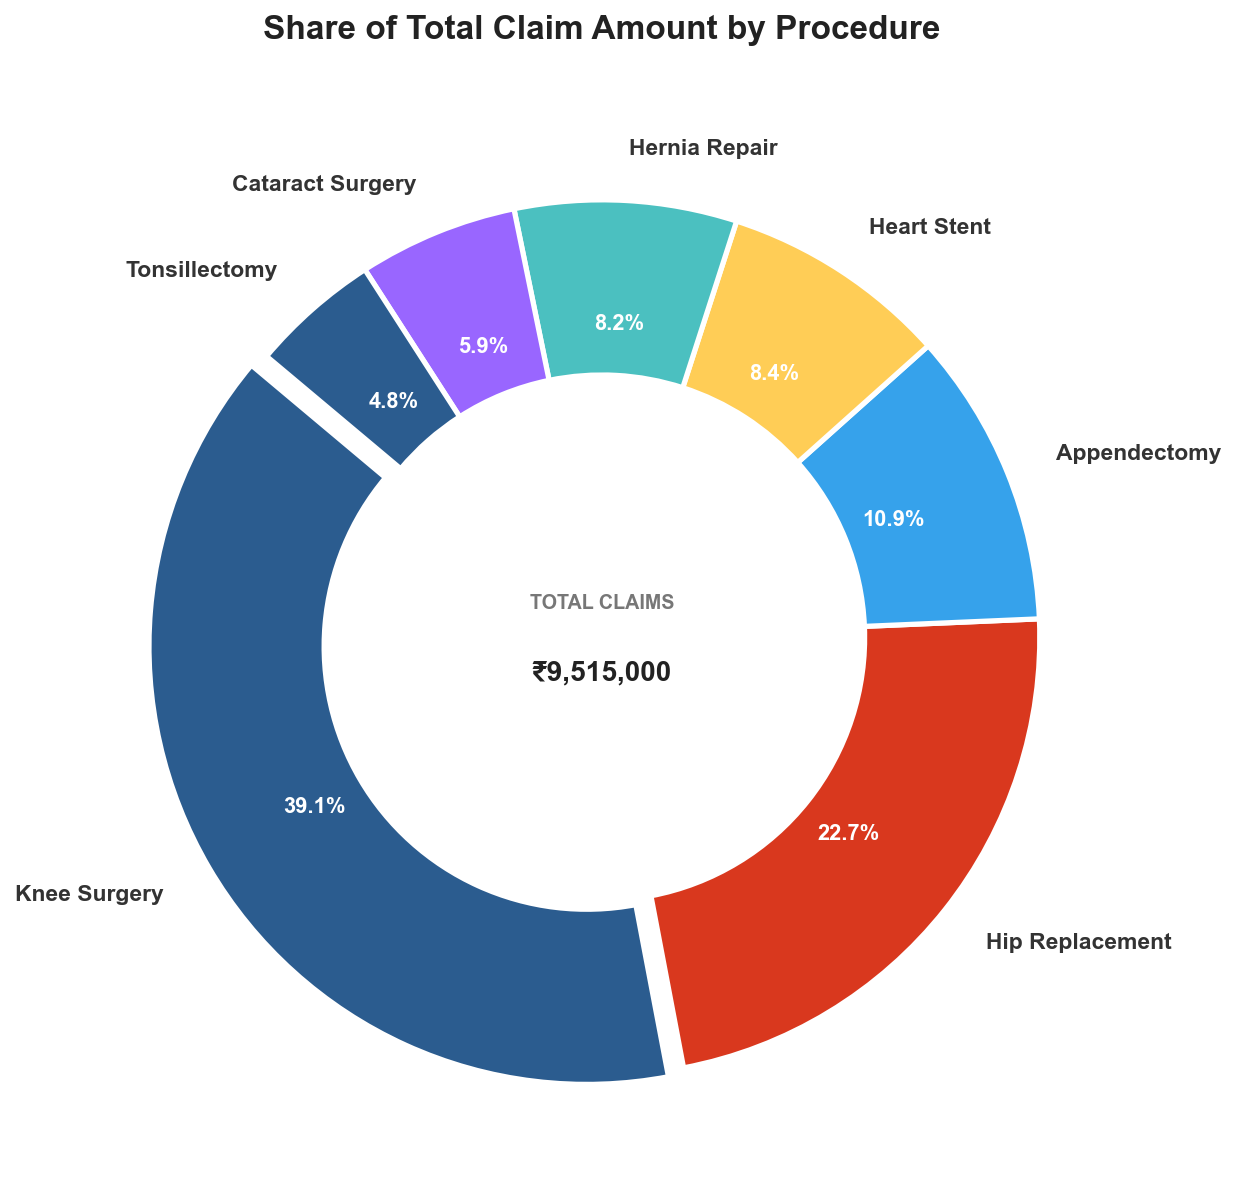

In [37]:
# Share of Total Claim Amount by Procedure

# Group data by procedure
procedure_total = (
    df.groupby("Procedure")["Claim Amount"]
    .sum()
    .sort_values(ascending=False)
)

total_claim_val = procedure_total.sum()

# Custom color palette
colors = ["#2b5c8f", "#d9381e", "#36a2eb", "#ffcd56", "#4bc0c0", "#9966ff"]

plt.figure(figsize=(8.5, 8.5), dpi=150)

# Explode the largest slice slightly for emphasis
explode_vals = [0.04] + [0] * (len(procedure_total) - 1)

wedges, texts, autotexts = plt.pie(
    procedure_total,
    labels=procedure_total.index,
    startangle=140,
    explode=explode_vals,
    autopct="%1.1f%%",
    pctdistance=0.72,
    labeldistance=1.12,
    colors=colors[: len(procedure_total)],
    wedgeprops=dict(
        width=0.40, edgecolor="white", linewidth=2.5, antialiased=True
    ),
)

# Beautify slice text labels
plt.setp(texts, fontsize=11, fontweight="bold", color="#333333")

# Beautify percentage labels
plt.setp(autotexts, fontsize=10.5, fontweight="bold", color="white")

# Center Summary Callout inside the donut hole
plt.gca().text(
    0,
    0.08,
    "TOTAL CLAIMS",
    ha="center",
    va="center",
    fontsize=9.5,
    fontweight="bold",
    color="#777777",
)

plt.gca().text(
    0,
    -0.08,
    f"₹{total_claim_val:,.0f}",
    ha="center",
    va="center",
    fontsize=13.5,
    fontweight="bold",
    color="#222222",
)

plt.title(
    "Share of Total Claim Amount by Procedure",
    fontsize=16,
    fontweight="bold",
    pad=25,
    color="#222222",
)

plt.tight_layout()
plt.show()

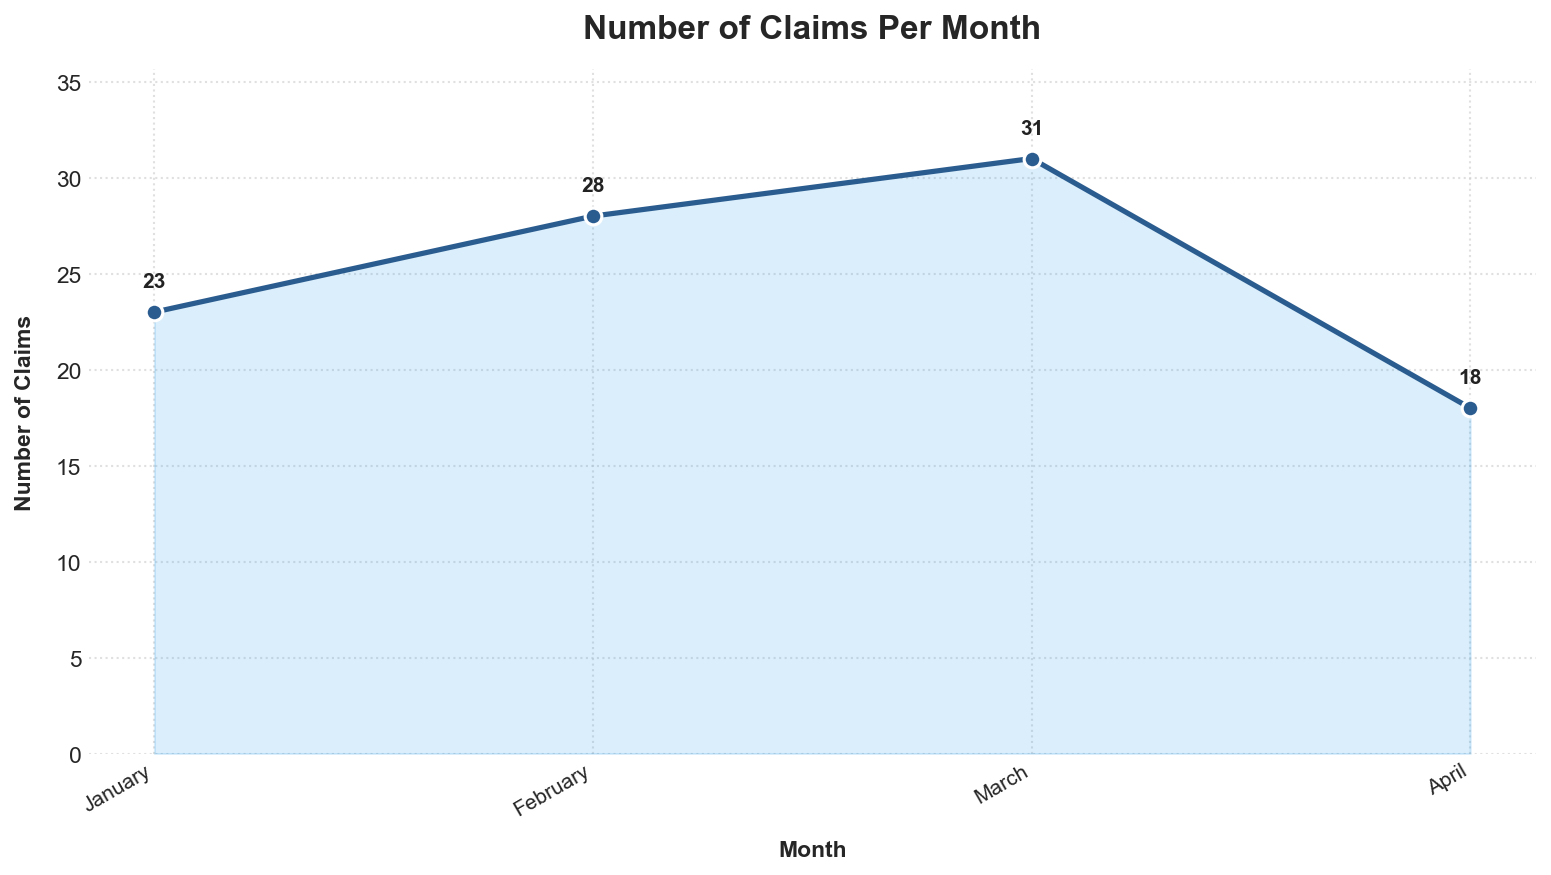

In [38]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract full month names
df["Month"] = df["Date"].dt.strftime("%B")

# Count number of claims per month
monthly_claims = (
    df.groupby("Month").size().reset_index(name="Number of Claims")
)

# Ensure months appear in calendar order
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_claims["Month"] = pd.Categorical(
    monthly_claims["Month"], categories=month_order, ordered=True
)

monthly_claims = monthly_claims.sort_values("Month")

# Theme setup
plt.style.use("seaborn-v0_8-whitegrid")

# Plot setup
fig, ax = plt.subplots(figsize=(10.5, 6), dpi=150)

# Colors
LINE_COLOR = "#2b5c8f"
FILL_COLOR = "#36a2eb"

# Plot trend line
ax.plot(
    monthly_claims["Month"],
    monthly_claims["Number of Claims"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=LINE_COLOR,
    markeredgecolor="white",
    markeredgewidth=1.5,
    zorder=3,
)

# Soft gradient-like fill underneath line
ax.fill_between(
    monthly_claims["Month"],
    monthly_claims["Number of Claims"],
    color=FILL_COLOR,
    alpha=0.18,
    zorder=2,
)

# Calculate dynamic text offset based on data range
max_claims = (
    monthly_claims["Number of Claims"].max()
    if not monthly_claims.empty
    else 1
)
offset = max_claims * 0.035

# Add data labels
for x, y in zip(monthly_claims["Month"], monthly_claims["Number of Claims"]):
    ax.text(
        x,
        y + offset,
        str(y),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222",
    )

# Title & Labels
ax.set_title(
    "Number of Claims Per Month", fontsize=16, fontweight="bold", pad=15
)
ax.set_xlabel("Month", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("Number of Claims", fontsize=11, fontweight="bold", labelpad=10)

# Axis & Grid Formatting
plt.xticks(rotation=30, ha="right", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6, color="#cccccc", zorder=1)

# Extend Y-axis upper limit to make room for text annotations
ax.set_ylim(bottom=0, top=max_claims * 1.15)

# Remove border spines for modern aesthetic
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

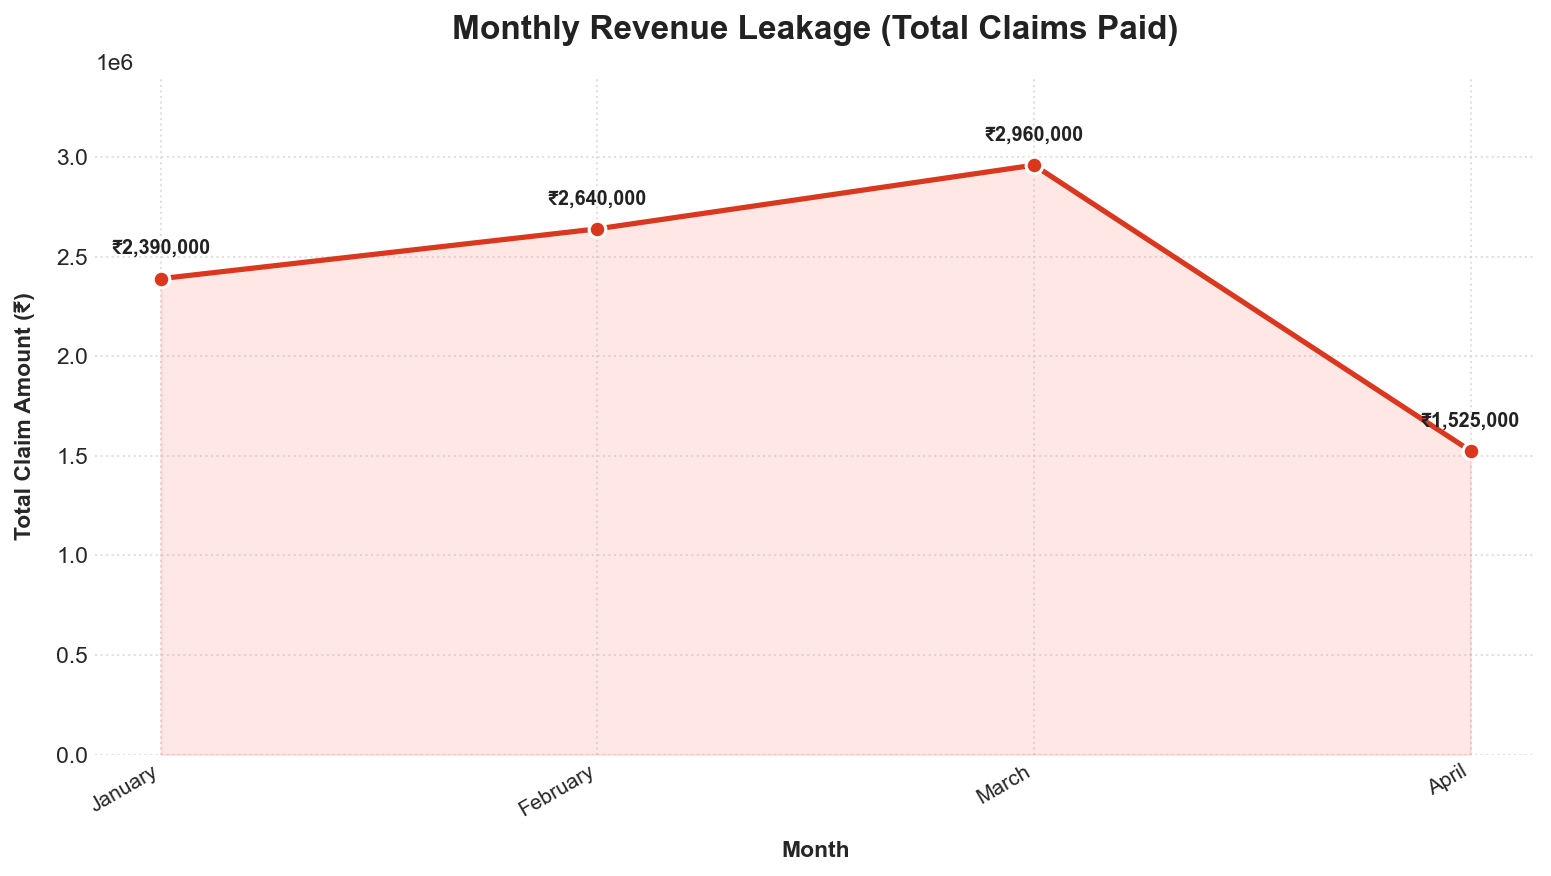

In [39]:

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create month names
df["Month"] = df["Date"].dt.strftime("%B")

# Sum claim amount by month
monthly_leakage = (
    df.groupby("Month")["Claim Amount"].sum().reset_index()
)

# Arrange months in calendar order
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_leakage["Month"] = pd.Categorical(
    monthly_leakage["Month"], categories=month_order, ordered=True
)

monthly_leakage = monthly_leakage.sort_values("Month")

# Color palette (Crimson / Alert red theme for "leakage")
LINE_COLOR = "#d9381e"
FILL_COLOR = "#ff8a80"

# Plot setup
fig, ax = plt.subplots(figsize=(10.5, 6), dpi=150)

# Plot trend line
ax.plot(
    monthly_leakage["Month"],
    monthly_leakage["Claim Amount"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=LINE_COLOR,
    markeredgecolor="white",
    markeredgewidth=1.5,
    zorder=3,
)

# Soft area fill underneath
ax.fill_between(
    monthly_leakage["Month"],
    monthly_leakage["Claim Amount"],
    color=FILL_COLOR,
    alpha=0.20,
    zorder=2,
)

# Calculate dynamic vertical offset for text labels
max_val = (
    monthly_leakage["Claim Amount"].max()
    if not monthly_leakage.empty
    else 1
)
offset = max_val * 0.035

# Add value labels
for x, y in zip(monthly_leakage["Month"], monthly_leakage["Claim Amount"]):
    ax.text(
        x,
        y + offset,
        f"₹{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color="#222222",
    )

# Title & Axis Labels
ax.set_title(
    "Monthly Revenue Leakage (Total Claims Paid)",
    fontsize=16,
    fontweight="bold",
    pad=18,
    color="#222222",
)
ax.set_xlabel("Month", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel(
    "Total Claim Amount (₹)", fontsize=11, fontweight="bold", labelpad=10
)

# Rotated month ticks & Grid
plt.xticks(rotation=30, ha="right", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6, color="#cccccc", zorder=1)

# Set headroom for text annotations
ax.set_ylim(bottom=0, top=max_val * 1.15)

# Remove border spines for clean look
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

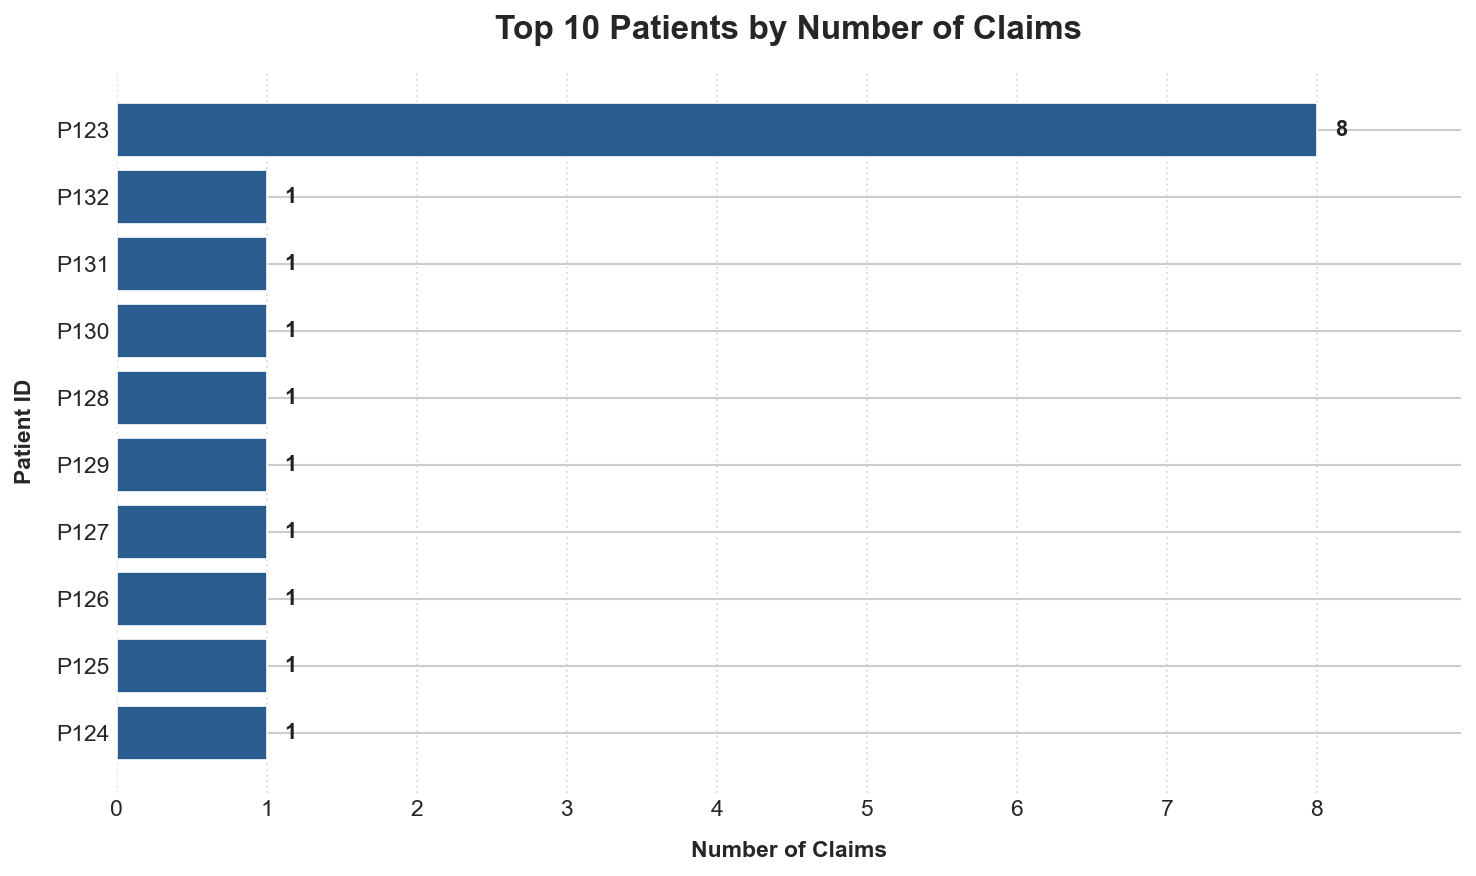

In [40]:

# Top 10 Patients by Number of Claims


# Clean theme setup
plt.style.use("seaborn-v0_8-whitegrid")

# Count number of claims per patient
patient_claims = (
    df["Patient ID"]
    .value_counts()
    .head(10)
    .sort_values()
)

# Plot setup
plt.figure(figsize=(10, 6), dpi=150)

# Horizontal Bar Chart
bars = plt.barh(
    patient_claims.index,
    patient_claims.values,
    color="#2b5c8f",
    edgecolor="white",
    linewidth=0.8,
    zorder=2,
)

# Dynamic offset calculation based on maximum claim count
max_val = patient_claims.max() if not patient_claims.empty else 1
offset = max_val * 0.015

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color="#222222",
    )

# Title & Axis Labels
plt.title(
    "Top 10 Patients by Number of Claims",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Claims", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Patient ID", fontsize=11, fontweight="bold", labelpad=10)

# Grid & Axis Padding
plt.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc", zorder=1)
plt.xlim(0, max_val * 1.12)

# Remove border spines for a modern, executive layout
ax = plt.gca()
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

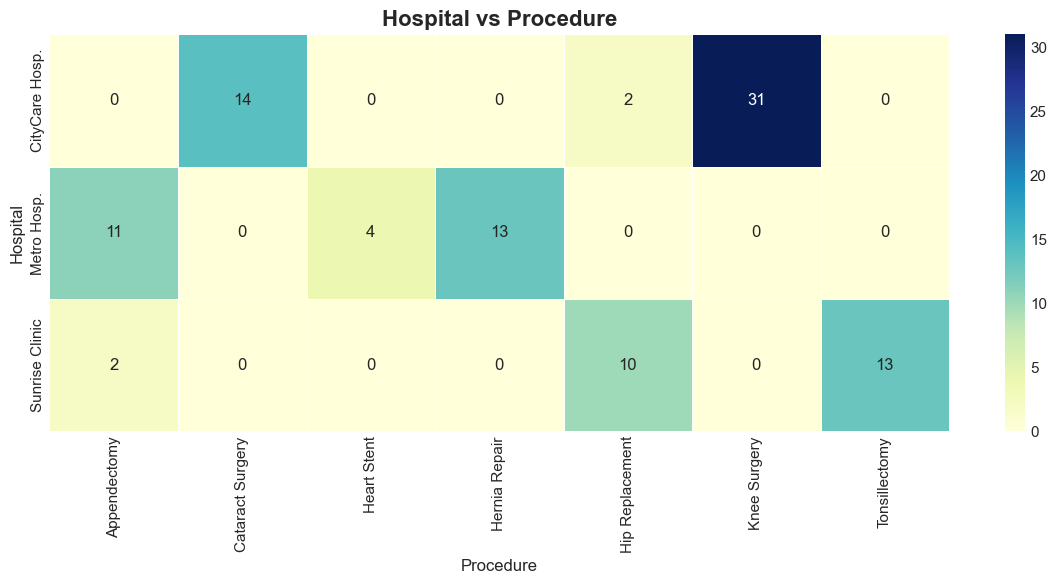

In [41]:
# Hospital vs Procedure Heatmap=

import seaborn as sns
import matplotlib.pyplot as plt

# Create pivot table
hospital_procedure = pd.crosstab(
    df["Hospital Name"],
    df["Procedure"]
)

# Plot heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    hospital_procedure,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Hospital vs Procedure", fontsize=16, fontweight="bold")
plt.xlabel("Procedure")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

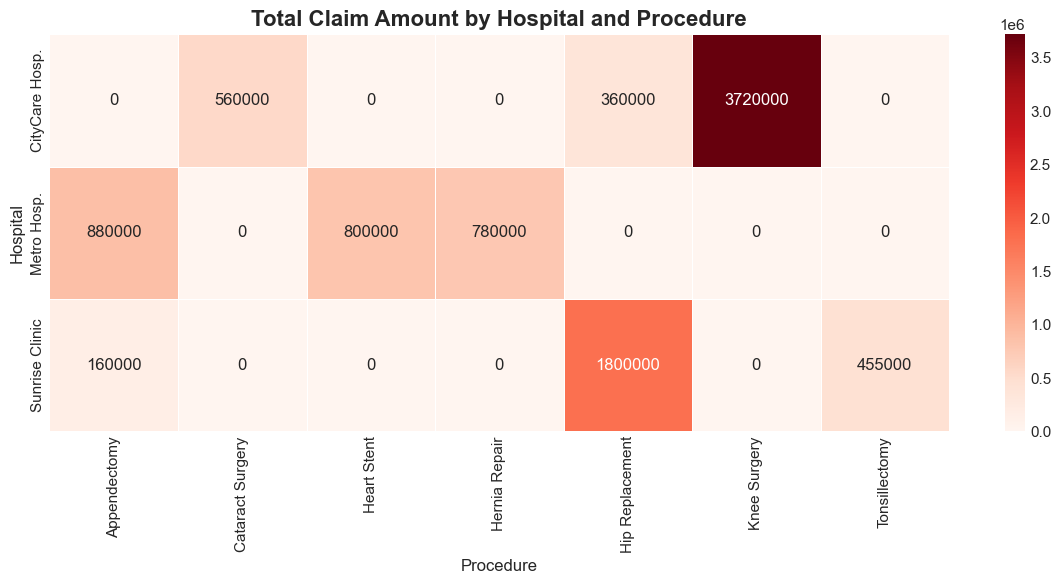

In [42]:
# Hospital vs Procedure (Total Claim Amount)

hospital_procedure_cost = pd.pivot_table(
    df,
    values="Claim Amount",
    index="Hospital Name",
    columns="Procedure",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12,6))

sns.heatmap(
    hospital_procedure_cost,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Total Claim Amount by Hospital and Procedure",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Procedure")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

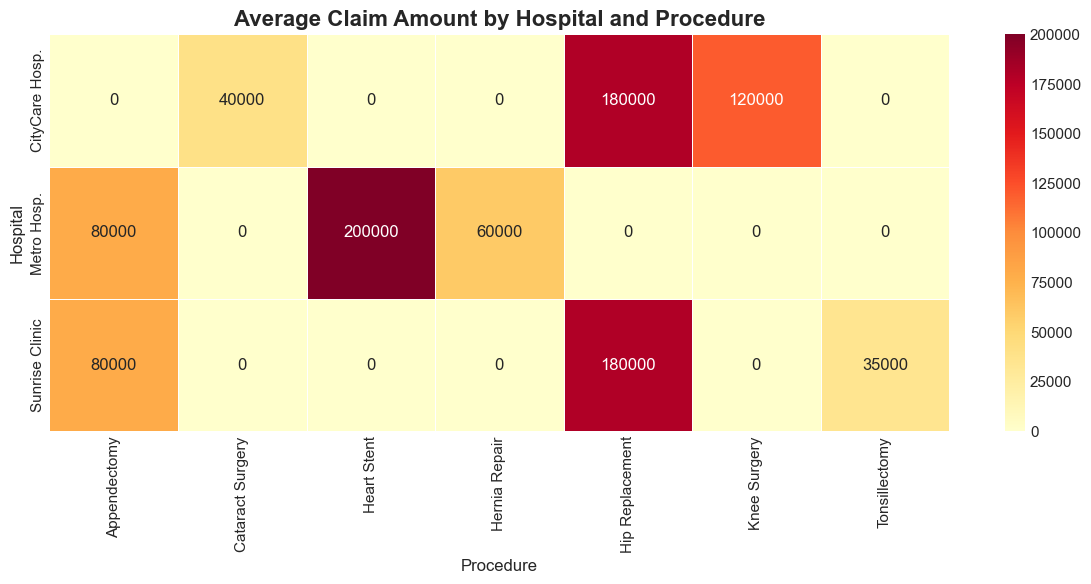

In [43]:
# Create pivot table

heatmap_data = pd.pivot_table(
    df,
    values="Claim Amount", 
    index="Hospital Name",
    columns="Procedure",
    aggfunc="mean",
    fill_value=0
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Average Claim Amount by Hospital and Procedure",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Procedure")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

In [44]:
# Display all claims for Patient P123

p123_claims = df[df["Patient ID"] == "P123"]

print("Potential Duplicate Claims for Patient P123")
print("-" * 45)
print(f"Total Claims: {len(p123_claims)}\n")

print(
    p123_claims[
        ["Claim ID", "Hospital Name", "Procedure", "Claim Amount", "Date"]
    ].to_string(index=False)
)

Potential Duplicate Claims for Patient P123
---------------------------------------------
Total Claims: 8

Claim ID  Hospital Name    Procedure  Claim Amount       Date
    C001 CityCare Hosp. Knee Surgery        120000 2025-01-10
    C002 CityCare Hosp. Knee Surgery        120000 2025-01-12
    C003 CityCare Hosp. Knee Surgery        120000 2025-01-15
    C006 CityCare Hosp. Knee Surgery        120000 2025-01-18
    C022 CityCare Hosp. Knee Surgery        120000 2025-01-29
    C023 CityCare Hosp. Knee Surgery        120000 2025-01-30
    C024 CityCare Hosp. Knee Surgery        120000 2025-02-01
    C100 CityCare Hosp. Knee Surgery        120000 2025-04-18


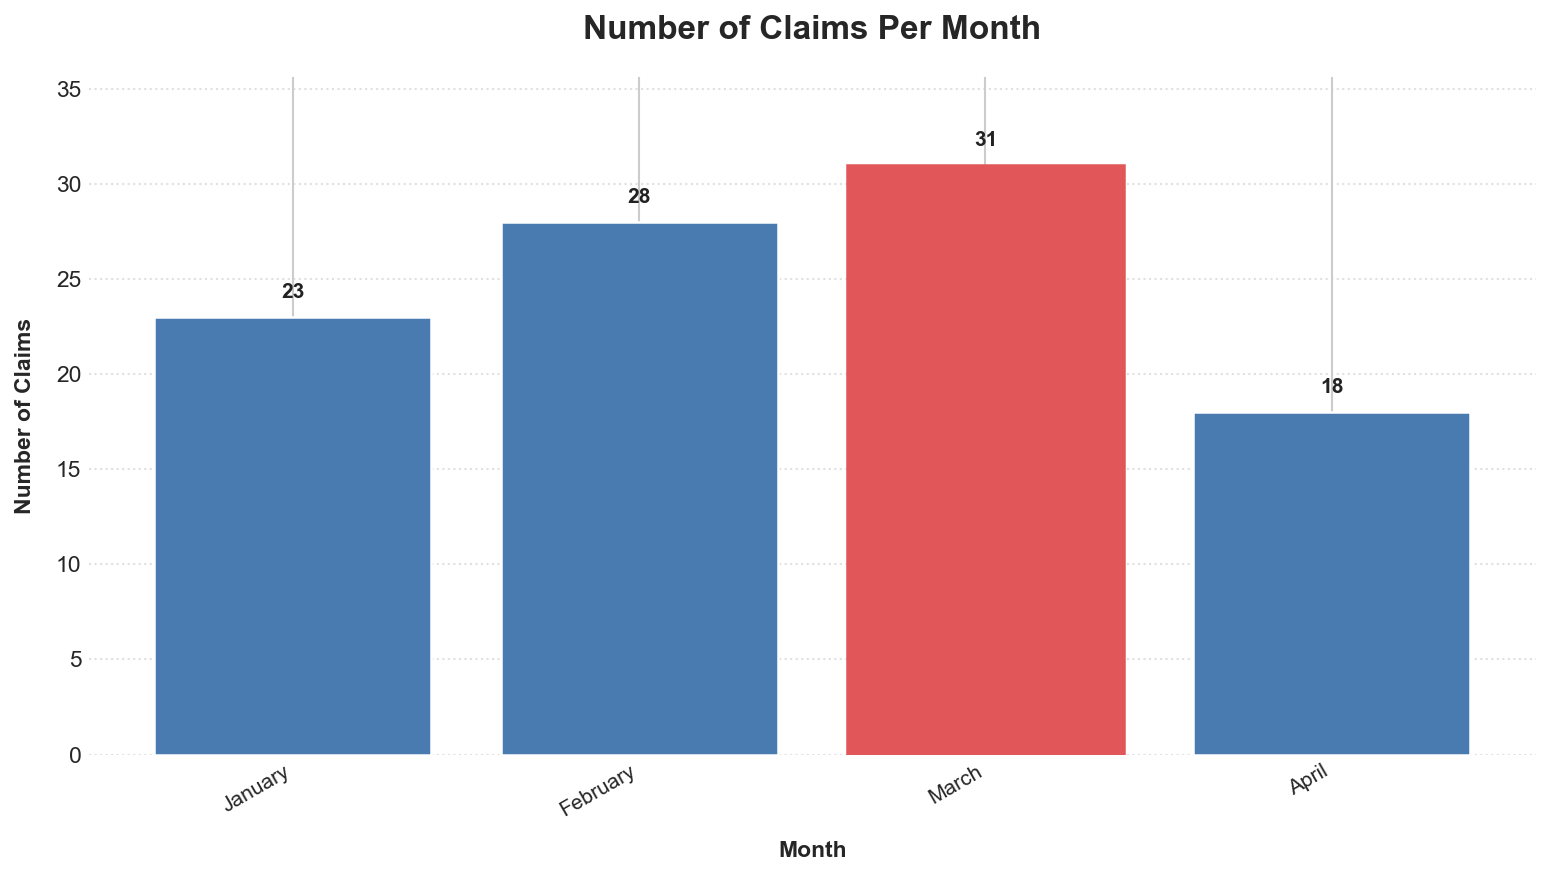

In [45]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract month name
df["Month"] = df["Date"].dt.month_name()

# Keep months in calendar order
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

df["Month"] = pd.Categorical(
    df["Month"], categories=month_order, ordered=True
)

# Count claims per month
monthly_claims = (
    df.groupby("Month", observed=True)
    .size()
    .reset_index(name="Number of Claims")
)

# Theme setup
plt.style.use("seaborn-v0_8-whitegrid")

# Plot setup
fig, ax = plt.subplots(figsize=(10.5, 6), dpi=150)

# Base bar chart with modern soft color
bars = ax.bar(
    monthly_claims["Month"],
    monthly_claims["Number of Claims"],
    color="#4A7BB0",
    edgecolor="white",
    linewidth=1.2,
    zorder=2,
)

# Highlight month with highest claims
max_idx = monthly_claims["Number of Claims"].idxmax()
bars[max_idx].set_color("#E15759")

# Dynamic vertical offset for data labels
max_val = (
    monthly_claims["Number of Claims"].max()
    if not monthly_claims.empty
    else 1
)
offset = max_val * 0.025

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + offset,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222",
    )

# Title & Axis Labels
ax.set_title(
    "Number of Claims Per Month", fontsize=16, fontweight="bold", pad=18
)
ax.set_xlabel("Month", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("Number of Claims", fontsize=11, fontweight="bold", labelpad=10)

# Ticks, Grid & Headroom
plt.xticks(rotation=30, ha="right", fontsize=10)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc", zorder=1)
ax.set_ylim(bottom=0, top=max_val * 1.15)

# Remove border spines for clean aesthetic
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

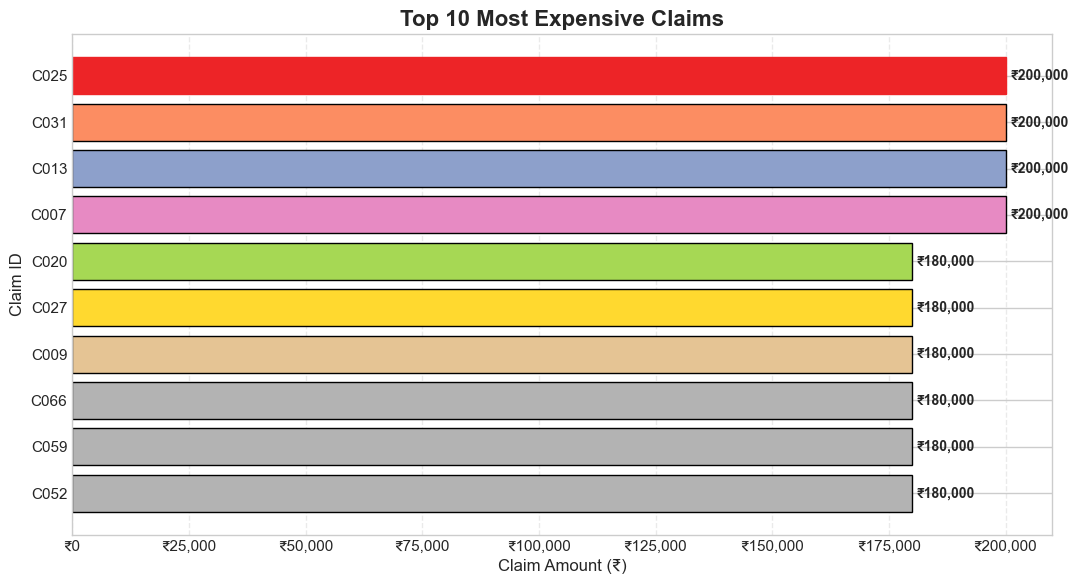

In [46]:
from matplotlib.ticker import StrMethodFormatter

# Top 10 most expensive claims
top_claims = (
    df.sort_values(by="Claim Amount", ascending=False)
      .head(10)
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_claims["Claim ID"],
    top_claims["Claim Amount"],
    color=plt.cm.Set2(range(len(top_claims))),
    edgecolor="black"
)

# Highest claim highlighted
bars[0].set_color("#ED2427")

# Value labels
for bar in bars:
    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f"₹{bar.get_width():,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
        
    )

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Most Expensive Claims",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Claim Amount (₹)")
plt.ylabel("Claim ID")

# Remove scientific notation
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

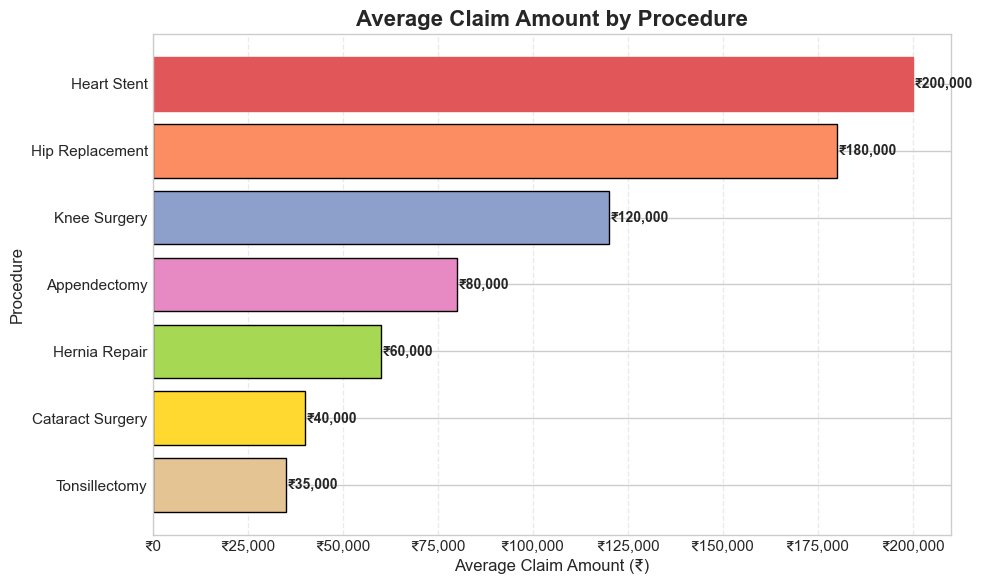

In [47]:
# Average Claim Amount per Procedure
avg_claim_procedure = (
    df.groupby("Procedure")["Claim Amount"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    avg_claim_procedure.index,
    avg_claim_procedure.values,
    color=plt.cm.Set2(range(len(avg_claim_procedure))),
    edgecolor="black"
)

# Highlight the highest average claim
bars[0].set_color("#E15759")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height()/2,
        f"₹{bar.get_width():,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))

plt.title("Average Claim Amount by Procedure", fontsize=16, fontweight="bold")
plt.xlabel("Average Claim Amount (₹)")
plt.ylabel("Procedure")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [48]:
claim_frequency = len(df) / df["Patient ID"].nunique()

print(f"Average Number of Claims per Patient: {claim_frequency:.2f}")

Average Number of Claims per Patient: 1.08


In [49]:
# Exclude P123

df_filtered = df[df["Patient ID"] != "P123"]

print(f"Number of Claims      : {df_filtered['Claim Amount'].count()}")
print(f"Average Claim Amount  : ₹{df_filtered['Claim Amount'].mean():,.2f}")
print(f"Median Claim Amount   : ₹{df_filtered['Claim Amount'].median():,.2f}")
print(f"Mode Claim Amount     : ₹{df_filtered['Claim Amount'].mode().iloc[0]:,.2f}")
print(f"Minimum Claim Amount  : ₹{df_filtered['Claim Amount'].min():,.2f}")
print(f"Maximum Claim Amount  : ₹{df_filtered['Claim Amount'].max():,.2f}")
print(f"Standard Deviation    : ₹{df_filtered['Claim Amount'].std():,.2f}")
print(f"Variance              : ₹{df_filtered['Claim Amount'].var():,.2f}")

Number of Claims      : 92
Average Claim Amount  : ₹92,989.13
Median Claim Amount   : ₹80,000.00
Mode Claim Amount     : ₹120,000.00
Minimum Claim Amount  : ₹35,000.00
Maximum Claim Amount  : ₹200,000.00
Standard Deviation    : ₹52,707.26
Variance              : ₹2,778,054,825.61
